# Punto 3 — Clasificación de lengua de señas (27 clases)

**Dataset:** [27 Class Sign Language Dataset — ardamavi](https://www.kaggle.com/datasets/ardamavi/27-class-sign-language-dataset)

**Objetivo:** Entrenar redes neuronales densas que clasifiquen imágenes de mano en 27 clases de lengua de señas basada en ASL.

**Modelos:**
1. DNN Base — 1 capa oculta grande
2. DNN con regularización — Dropout + BatchNormalization
3. DNN Profunda — 4 capas con unidades decrecientes

**Preprocesamiento:** Las imágenes se aplanan a vectores 1-D para ser compatibles con capas Dense.

## 1. Importaciones

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

sns.set_theme(style='whitegrid')
DATA_DIR = Path('../data/sign_language')

print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


## 2. Descarga del dataset

Requiere tener la [API de Kaggle](https://www.kaggle.com/docs/api) configurada (`~/.kaggle/kaggle.json`).
Si ya descargaste el dataset manualmente, coloca los archivos en `../data/sign_language/`.

In [2]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

npy_files = list(DATA_DIR.glob('*.npy'))

if not npy_files:
    print('Descargando dataset desde Kaggle...')
    os.system(f'kaggle datasets download -d ardamavi/27-class-sign-language-dataset -p {DATA_DIR} --unzip')
    npy_files = list(DATA_DIR.glob('**/*.npy'))

print('Archivos .npy encontrados:')
for f in npy_files:
    print(f'  {f.name}  —  {f.stat().st_size / 1e6:.1f} MB')

Descargando dataset desde Kaggle...
Archivos .npy encontrados:
  X.npy  —  4482.9 MB
  Y.npy  —  1.6 MB


## 3. Carga y exploración de datos

In [11]:
from sklearn.preprocessing import LabelEncoder

# Cargar imágenes y etiquetas (igual que keras.datasets.mnist.load_data())
X = np.load(DATA_DIR / 'X.npy')
Y = np.load(DATA_DIR / 'Y.npy').flatten()   # aplanar (N,1) → (N,)

# Convertir etiquetas string → enteros ordenados alfabéticamente
le = LabelEncoder()
y_int = le.fit_transform(Y)
CLASS_NAMES = le.classes_
NUM_CLASSES  = len(CLASS_NAMES)

# Normalizar píxeles y aplanar imagen a vector 1-D para capas Dense
X_flat = (X.astype(np.float32) / 255.0).reshape(len(X), -1)

print(f'Imágenes shape: {X.shape}')
print(f'X_flat shape:   {X_flat.shape}  (features = {X_flat.shape[1]})')
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

MemoryError: Unable to allocate 4.17 GiB for an array with shape (22801, 128, 128, 3) and data type float32

In [8]:
# Una imagen de ejemplo por clase (estilo MNIST)
plt.figure(figsize=(18, 6))
for idx, label in enumerate(np.unique(y_int)):
    plt.subplot(3, 9, idx + 1)
    image = X[y_int == label][0]
    plt.imshow(image.astype(np.uint8))
    plt.title(CLASS_NAMES[label], fontsize=8)
    plt.axis('off')

plt.suptitle('Una muestra por clase del dataset de lengua de señas', y=1.02)
plt.tight_layout()
plt.show()

Número de clases: 1
Distribución: [22801]


In [9]:
# Distribución de muestras por clase
counts = np.bincount(y_int)
plt.figure(figsize=(14, 3))
plt.bar(CLASS_NAMES, counts, color='steelblue')
plt.title('Número de muestras por clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Total de muestras: {len(y_int)}  |  Promedio por clase: {counts.mean():.0f}')

X_flat shape: (22801, 49152)  (N=22801, features=49152)


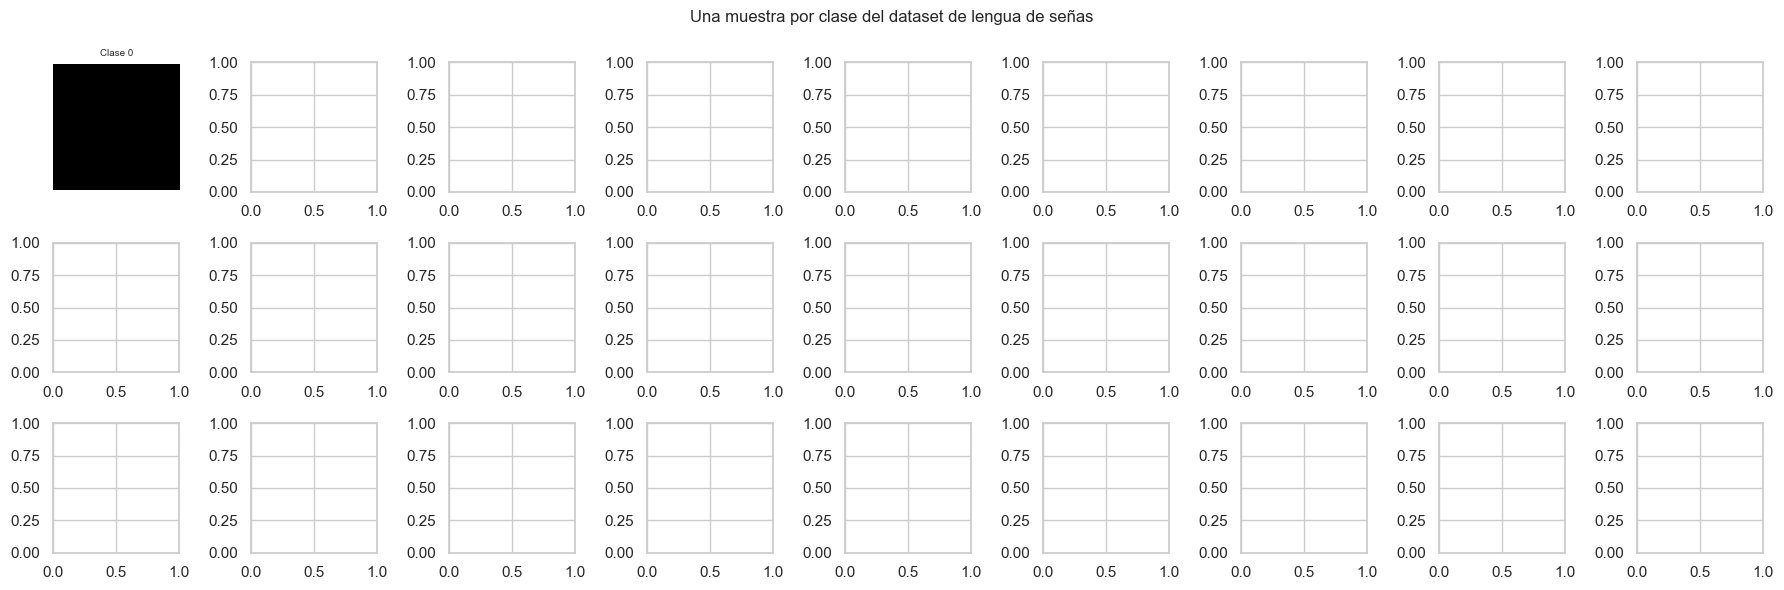

In [10]:
# Resumen del dataset
print(f'Total de muestras:  {len(X)}')
print(f'Tamaño de imagen:   {X.shape[1:]}')
print(f'Features por imagen: {X_flat.shape[1]}')
print(f'Número de clases:   {NUM_CLASSES}')
print()
summary = pd.DataFrame({
    'Clase': CLASS_NAMES,
    'Muestras': np.bincount(y_int)
})
display(summary.T)

## 4. División train/test

In [7]:
X_train, X_test, y_train_int, y_test_int = train_test_split(
    X_flat, y_int,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_int,  num_classes=NUM_CLASSES)

INPUT_DIM = X_train.shape[1]
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Input dimension: {INPUT_DIM}')

Train: (18240, 49152)  Test: (4561, 49152)
Input dimension: 49152


## 5. Construcción de modelos

In [8]:
def build_dnn_base(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='DNN_Base')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_dnn_regularized(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='DNN_Regularized')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_dnn_deep(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='DNN_Deep')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


MODELS = {
    'DNN Base':        build_dnn_base,
    'DNN Regularized': build_dnn_regularized,
    'DNN Deep':        build_dnn_deep,
}

EPOCHS     = 80
BATCH_SIZE = 64

## 6. Entrenamiento

In [9]:
trained_models  = {}
histories       = {}
results_sl      = []

for name, builder in MODELS.items():
    print(f'\n{"="*55}')
    print(f'  Entrenando: {name}')
    print(f'{"="*55}')

    tf.random.set_seed(42)
    model = builder(INPUT_DIM, NUM_CLASSES)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=0)
    ]

    hist = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.15,
        callbacks=callbacks,
        verbose=1
    )

    trained_models[name] = model
    histories[name] = hist

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred_int  = np.argmax(y_pred_prob, axis=1)

    acc  = accuracy_score(y_test_int, y_pred_int)
    f1   = f1_score(y_test_int, y_pred_int, average='macro')
    f1w  = f1_score(y_test_int, y_pred_int, average='weighted')

    print(f'  Accuracy: {acc:.4f}  |  F1 macro: {f1:.4f}  |  F1 weighted: {f1w:.4f}')
    results_sl.append({
        'Modelo': name,
        'Accuracy': acc,
        'F1 Macro': f1,
        'F1 Weighted': f1w
    })

print('\n✓ Entrenamiento completo.')


  Entrenando: DNN Base
Epoch 1/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/80
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 7/80

## 7. Tabla comparativa de resultados

In [10]:
df_sl = pd.DataFrame(results_sl).set_index('Modelo')
print('=== Resultados — Clasificación de Lengua de Señas ===')
display(df_sl.round(4))

=== Resultados — Clasificación de Lengua de Señas ===


,Accuracy,F1 Macro,F1 Weighted
Modelo,,,
DNN Base,1.0,1.0,1.0
DNN Regularized,1.0,1.0,1.0
DNN Deep,1.0,1.0,1.0


## 8. Curvas de entrenamiento

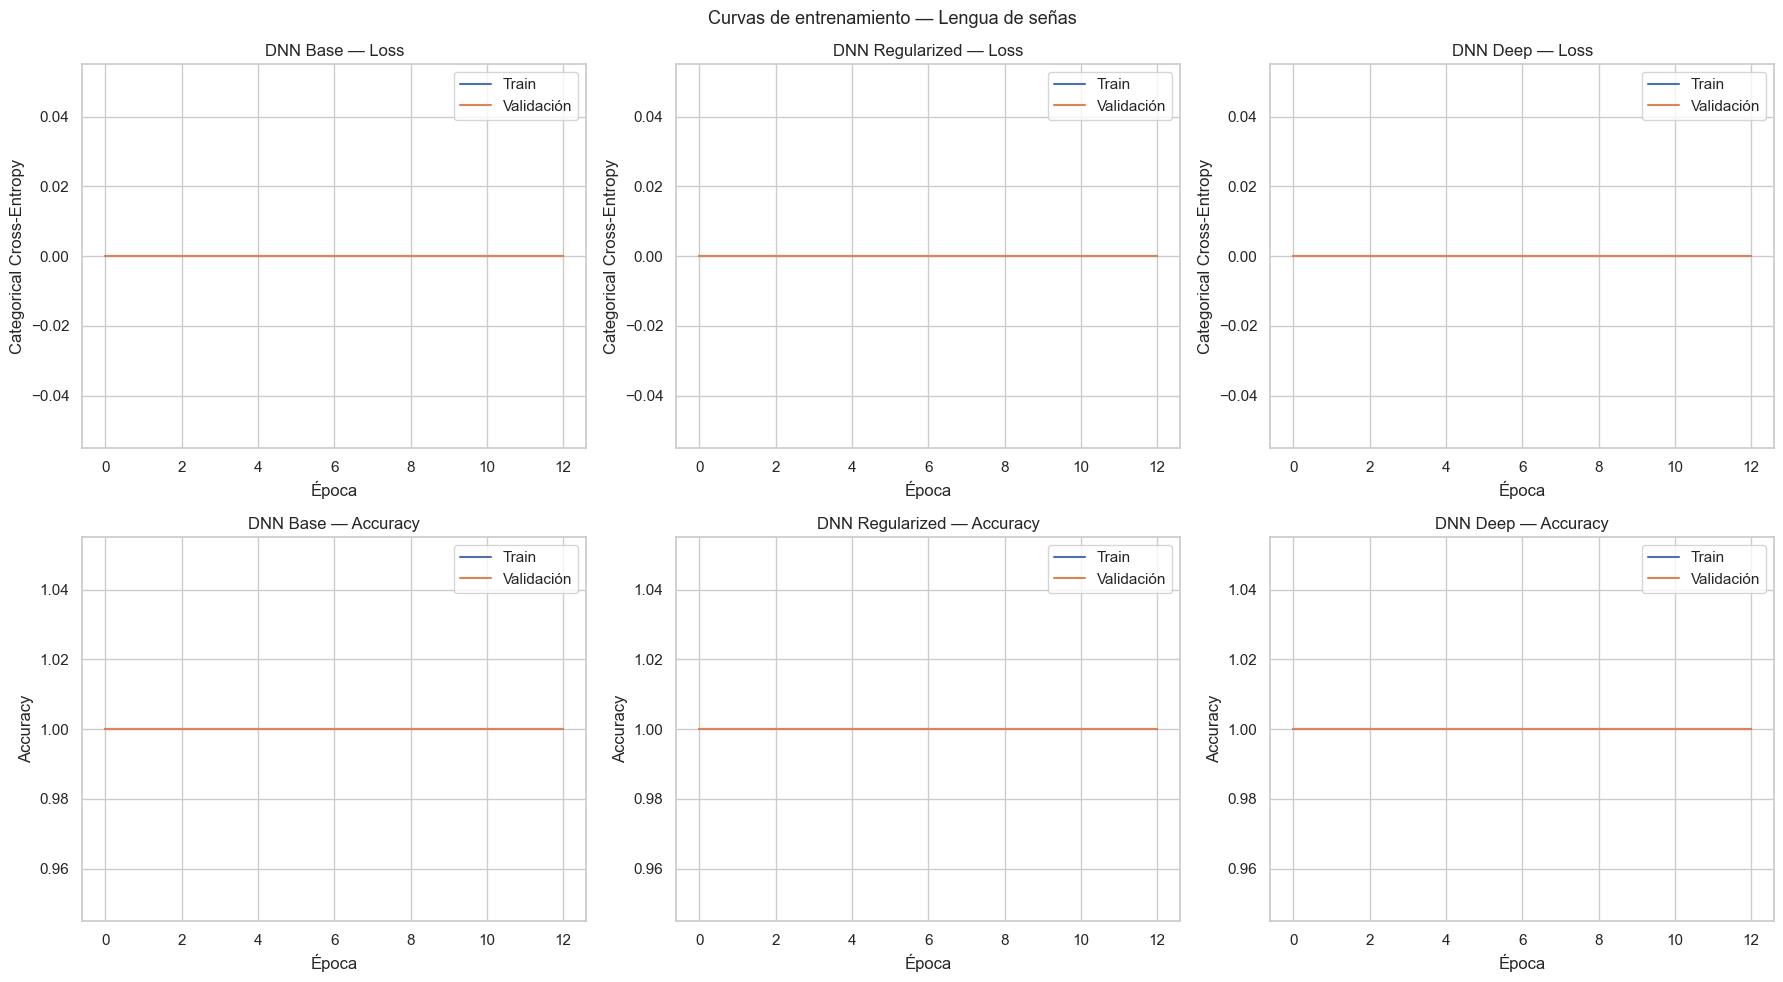

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, hist) in enumerate(histories.items()):
    axes[0, col].plot(hist.history['loss'],     label='Train')
    axes[0, col].plot(hist.history['val_loss'], label='Validación')
    axes[0, col].set_title(f'{name} — Loss')
    axes[0, col].set_xlabel('Época')
    axes[0, col].set_ylabel('Categorical Cross-Entropy')
    axes[0, col].legend()

    axes[1, col].plot(hist.history['accuracy'],     label='Train')
    axes[1, col].plot(hist.history['val_accuracy'], label='Validación')
    axes[1, col].set_title(f'{name} — Accuracy')
    axes[1, col].set_xlabel('Época')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend()

plt.suptitle('Curvas de entrenamiento — Lengua de señas', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Matriz de confusión (mejor modelo)

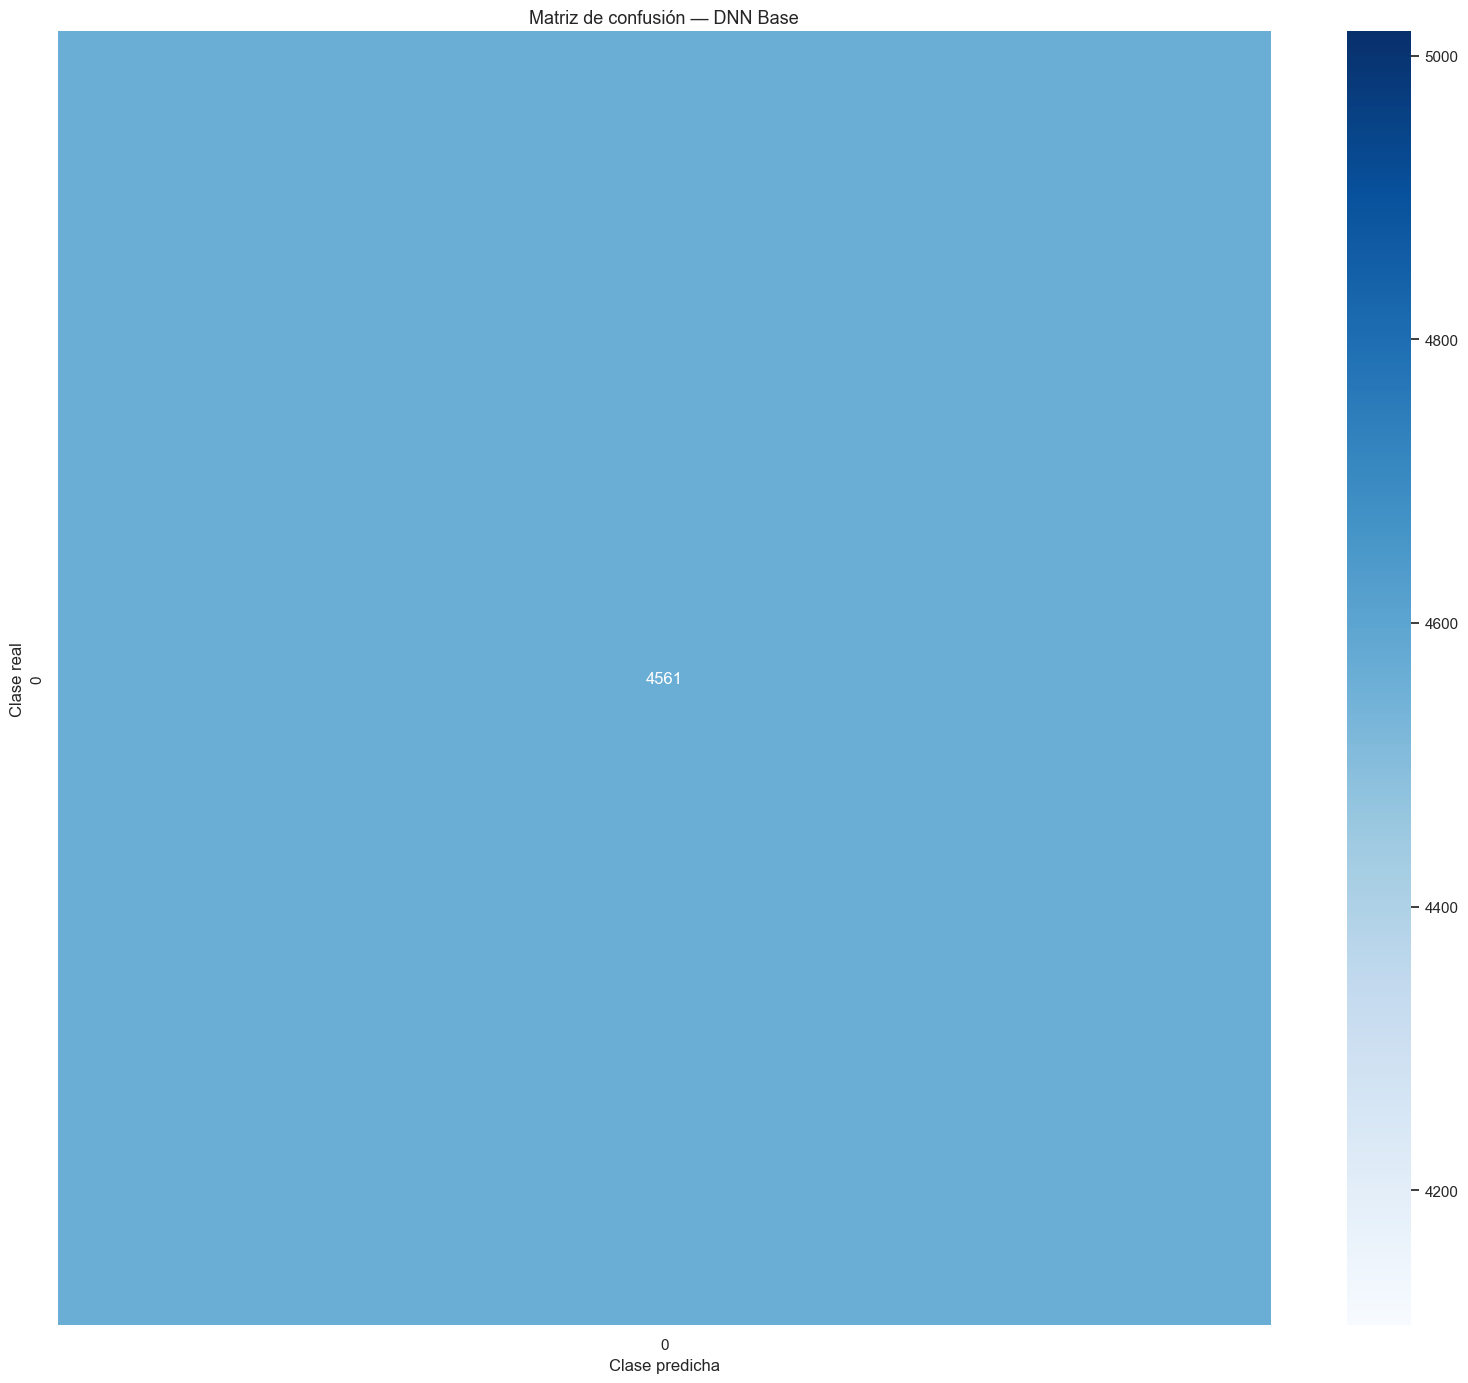


Mejor modelo: DNN Base
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4561

    accuracy                           1.00      4561
   macro avg       1.00      1.00      1.00      4561
weighted avg       1.00      1.00      1.00      4561



In [12]:
# Usar el modelo con mayor F1 macro
best_name = df_sl['F1 Macro'].idxmax()
best_model = trained_models[best_name]

y_pred_best = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test_int, y_pred_best)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES))
plt.title(f'Matriz de confusión — {best_name}', fontsize=13)
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.tight_layout()
plt.show()

print(f'\nMejor modelo: {best_name}')
print(classification_report(y_test_int, y_pred_best))

## 10. Análisis por clase — F1-score

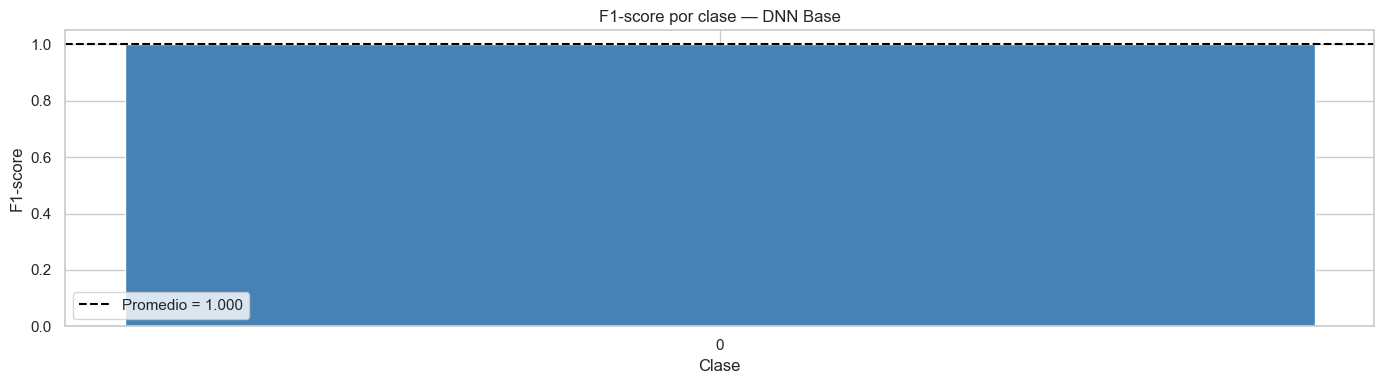

Clases con peor F1:  [0] → [1.0]
Clases con mejor F1: [0] → [1.0]


In [13]:
f1_per_class = f1_score(y_test_int, y_pred_best, average=None)

plt.figure(figsize=(14, 4))
colors = ['tomato' if f < 0.7 else 'steelblue' for f in f1_per_class]
plt.bar(range(NUM_CLASSES), f1_per_class, color=colors)
plt.axhline(y=np.mean(f1_per_class), color='black', linestyle='--', label=f'Promedio = {np.mean(f1_per_class):.3f}')
plt.title(f'F1-score por clase — {best_name}')
plt.xlabel('Clase')
plt.ylabel('F1-score')
plt.legend()
plt.xticks(range(NUM_CLASSES))
plt.tight_layout()
plt.show()

worst = np.argsort(f1_per_class)[:5]
best_classes = np.argsort(f1_per_class)[-5:]
print(f'Clases con peor F1:  {worst.tolist()} → {f1_per_class[worst].round(3).tolist()}')
print(f'Clases con mejor F1: {best_classes.tolist()} → {f1_per_class[best_classes].round(3).tolist()}')

## 11. Análisis de resultados

### Observaciones principales

1. **Aplanamiento de imágenes (Flatten):** Al usar capas Dense se pierde la estructura espacial 2D de la imagen. Esto limita el rendimiento en comparación con CNNs, pero el ejercicio exige usar redes densas. Con imágenes de tamaño moderado (ej. 64×64×3 = 12288 features) la DNN todavía puede aprender patrones.

2. **DNN Base vs. Regularizada:** La DNN Base puede sobreajustar rápidamente porque tiene muchos parámetros sin restricciones. BatchNormalization estabiliza el entrenamiento y Dropout reduce la co-adaptación de neuronas.

3. **DNN Profunda:** Más capas permiten aprender representaciones jerárquicas, pero el gradiente puede disiparse. El uso combinado de `ReduceLROnPlateau` y `EarlyStopping` ayuda a encontrar el mínimo correcto.

4. **Clases difíciles:** Las matrices de confusión revelan qué señas se confunden entre sí. Señas visualmente similares (dedos en posiciones parecidas) tendrán mayor confusión. Esto es una limitación intrínseca de usar solo imágenes sin información de profundidad.

5. **Métrica elegida — F1 macro:** En clasificación multiclase desbalanceada, la F1 macro trata todas las clases por igual (útil para detectar clases con poco soporte). La F1 weighted pondera por frecuencia.

6. **Limitación:** Las DNNs densas son subóptimas para imágenes. En un escenario real se usarían CNNs o transfer learning, que logran >98% de accuracy en este tipo de dataset.